# import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import os
import time

In [2]:
import statannotations
from statannotations.Annotator import Annotator #https://doi.org/10.5281/zenodo.7213391
statannotations.__version__

'0.7.2'

In [3]:
!python --version

Python 3.10.15


In [4]:
# change here to your dir
data_dir = '/{your raw_data}'
save_dir = '/{your export_data}'
ML_dir = '/{Machine Learning dir}'

In [35]:
#Global parameter. Adjust the font size of the entire image.
plt.rcParams['font.family'] = 'Arial'
sns.set(font='Arial')
sns.set_context("paper", font_scale=1.5)  #font_scale: Zoom factor, commonly use 1.2~2.0

# function

In [8]:
import pickle
def my_pickle(mode='save', name='my_pickle.pickle', fold=None,
              path=os.path.join(save_dir,'pickle_file'), **arg):
    if fold == None:
        fold_path = path
    else:
        fold_path = os.path.join(path, fold)
    if not os.path.exists(fold_path):   #create fold if not exist
        os.makedirs(fold_path)
    save_path = os.path.join(fold_path, name)
    if mode == 'save':
        picklefile = open(save_path, 'wb') # wb, binary write
        pickle.dump(arg['data'], picklefile)  #dump
        picklefile.close()
    elif mode == 'load':
        pkfile = open(save_path, 'rb') # rb, binary read
        data = pickle.load(pkfile)
        pkfile.close()
        return data

In [9]:
class EV():
    def __init__(self, cell_type, date, confidence, d_max=350, max_range=None, min_dots=100, 
                 init_run=True, save_tensor=True, save_all=False, data_dir=data_dir, discard_drift=False,
                 single_protein=False):
        self.type = cell_type
        self.date = date
        self.confi = confidence
        self.discard_drift = discard_drift
        self.single_protein = single_protein
        self.header = 2
        #self.shape = shape
        self.max_range = max_range
        self.min_dots = min_dots
        self.d_max = d_max
        self.save_tensor = save_tensor
        self.save_all = save_all
        self.export_dir = os.path.join(save_dir, '/pickle_file')
        self.data_dir = data_dir
        
        if init_run == True:
            self.run_1()

    def load_csv(self, mode):
        if mode == 'R':
            path = os.path.join(self.data_dir, f"cluster(0-{self.confi})")
            self.ev = load_csv(path, 'R', self.header, self.discard_drift)
        elif mode == 'raw':
            path = os.path.join(self.data_dir, f"cluster raw(0-{self.confi})")
            self.raw = load_csv(path, 'raw', self.header, self.discard_drift)
    def find_EV_cluster(self):
        self.cluster = find_EV_cluster(self.ev, self.d_max, self.single_protein)
    def find_all_RGB_dots(self):
        self.coor = find_all_RGB_dots(self.cluster, self.ev, self.raw, self.min_dots, self.max_range)
    def find_max_xy(self):
        self.shape = find_max_xy(self.coor)
        print(self.shape)
    def batch_coor_to_sp(self):
        self.sp = batch_coor_to_sp(self.coor, self.shape)
    def dict_sparse_to_dense_tensor(self):
        self.tensor = dict_sparse_to_dense_tensor(self.sp)
    def sp_EV_concat(self):
        self.train = sp_EV_concat(self.tensor)
    
    def run_1(self):
        self.load_csv(mode='R')
        self.load_csv(mode='raw')
        self.find_EV_cluster()
        self.find_all_RGB_dots()
            
        if self.save_all == True:
            my_pickle(mode='save', fold='EV_all', 
                      name=f"{self.type}_{self.date}_{self.confi}_mindot{self.min_dots}_all.pickle", 
                      path=self.export_dir, data=self)
    
    def run_2(self, shape_2=None, save_all=True):
        if shape_2 is not None:
            self.shape = shape_2
        else:
            self.find_max_xy()
        
        self.batch_coor_to_sp()
        self.dict_sparse_to_dense_tensor()
        self.sp_EV_concat()
        
        if self.save_tensor == True:
            my_pickle(mode='save', 
                      name=f"{self.type}_{self.date}_{self.confi}_mindot{self.min_dots}_tensor.pickle", 
                      fold=f'EV_{self.confi}_tensor', 
                      path=self.export_dir, data=self.tensor)
            my_pickle(mode='save', 
                      name=f"{self.type}_{self.date}_{self.confi}_mindot{self.min_dots}_train.pickle", 
                      fold=f'EV_type_train_{self.confi}',
                      path=self.export_dir, data=self.train)
        if save_all == True:
            my_pickle(mode='save', fold='EV_all',
                      name=f"{self.type}_{self.date}_{self.confi}_mindot{self.min_dots}_all.pickle", 
                      path=self.export_dir, data=self)

In [10]:
def load_csv(fold_dir, mode, header=2, discard_drift=False):
    EV = dict()
    file_name = {'cd63':'CD63', 'epcam':'EpCAM', 'cd81':'CD81'}
    if mode == 'R':
        for fold in os.listdir(fold_dir):
            if (discard_drift == True) and ("drift big" in fold):
                continue  # if there is "drift big" in fold_name, skip it
                
            names=['ID_CLUSTER','Center_X','Center_Y','Center_Z','Nb locs','Volume','Density',
                   'Radius_gyration_X','Radius_gyration_Y','Radius_gyration_Z']
            usecols=[0,1,2,3,5,7,8,9]
            len_protein = {}
            ev = pd.DataFrame([])
            
            for csv in os.listdir(os.path.join(fold_dir, fold)):
                if csv != csv.lower(): # Change the file name to lowercase.
                    os.rename(os.path.join(fold_dir, fold, csv), os.path.join(fold_dir, fold, csv.lower())) #old_name, new_name
                    csv = csv.lower()
                    
                protein = pd.read_csv(os.path.join(fold_dir, fold, csv), usecols=usecols, header=header, names=names)
                p_name = file_name[os.path.splitext(csv.lower())[0]]
                protein['protein'] = [p_name]*len(protein)
                len_protein[p_name] = len(protein)
                ev = pd.concat([ev, protein], ignore_index=True)
            
            EV[fold] = [ev, len_protein]
            
    elif mode == 'raw':
        for fold in os.listdir(fold_dir):
            ev_dots = {}
            
            for csv in os.listdir(os.path.join(fold_dir, fold)):
                if csv != csv.lower():
                    os.rename(os.path.join(fold_dir, fold, csv), os.path.join(fold_dir, fold, csv.lower()))
                    csv = csv.lower()
                
                protein_dots = pd.read_csv(os.path.join(fold_dir, fold, csv))
                p_name = file_name[os.path.splitext(csv.lower())[0]]
                protein_dots['protein'] = [p_name]*len(protein_dots)
                
                ev_dots[p_name] = protein_dots
            
            EV[fold] = ev_dots
            
    return EV

In [98]:
A549_1_may_cluster#DBSCAN mode

{'2': {0: {0, 322, 1012},
  1: {1, 1231},
  2: {2, 945},
  4: {4, 942},
  7: {7, 1059},
  8: {8, 951},
  9: {9, 1048},
  10: {10, 219, 956, 1006},
  11: {11, 974},
  12: {12, 25, 40, 112, 382},
  13: {13, 968},
  14: {14, 965},
  15: {15, 38, 1108, 1109, 1125},
  16: {16, 1104},
  17: {17, 1083},
  18: {18,
   30,
   142,
   160,
   187,
   215,
   450,
   473,
   476,
   499,
   654,
   703,
   955,
   1064,
   1071,
   1098,
   1137,
   1138},
  19: {19, 1096, 1282},
  20: {20, 941, 1236},
  21: {21, 596, 1001, 1099, 1121},
  22: {22, 925, 926},
  24: {24, 1044},
  27: {27, 1268},
  28: {28,
   80,
   85,
   91,
   224,
   296,
   297,
   298,
   299,
   352,
   547,
   548,
   549,
   669,
   783,
   809,
   1008},
  29: {29, 785},
  31: {31, 1046, 1312, 1323},
  32: {32, 989, 1239},
  34: {34, 928, 1284},
  35: {35, 57, 911},
  37: {37, 39, 670, 787, 1260, 1309},
  42: {42, 1324},
  43: {43, 116},
  44: {44, 962},
  45: {45, 172, 207, 392, 602, 971, 1301, 1340},
  46: {46, 970},
  

In [11]:
def find_EV_cluster(data, d_max=350, single_protein=False, dist=False):
    'for dict(file fold)'
    EV_cluster=dict(); EV_distance=dict()
    for key in data:
        if dist == False:
            EV_cluster[key] = f_EV_cluster(data[key][0], d_max=d_max, single_protein=single_protein)
        else:
            EV_cluster[key], EV_distance[key] = f_EV_cluster(data[key][0], d_max=d_max, single_protein=single_protein)
    if dist == False:
        return EV_cluster
    else:
        return EV_cluster, EV_distance

In [12]:
from sklearn.cluster import DBSCAN
def f_EV_cluster(df, d_max=350, single_protein=False):
    '''
    d_max: number. (default = 350nm for lEV) Diameter threshold of one EV
    single_protein: [False or 'CD63']. If False, discard single protein. If 'CD63', add single 'CD63' protein
    '''
    EV_cluster=dict()
    EV_distance=dict()
    
    ev_coords = df[['Center_X', 'Center_Y', 'Center_Z',]].values
    clustering = DBSCAN(eps=d_max, min_samples=1).fit(ev_coords) #DBSCAN for Center (of multi-proteins), so min_samples=1.
    df['DBSCAN_id2'] = clustering.labels_
    
    
    for cluster_id in df['DBSCAN_id2'].unique():
        if cluster_id == -1:  #-1 means Noisy sample
            continue
        
        dataID_cluster_1 = df[df['DBSCAN_id2'] == cluster_id] 
        
        if len(dataID_cluster_1) > 1:  # discard single protein
            EV_cluster[dataID_cluster_1.index[0]] = set(dataID_cluster_1.index)
        elif (single_protein == 'CD63') & (single_protein in dataID_cluster_1['protein'].values):
            EV_cluster[dataID_cluster_1.index[0]] = set(dataID_cluster_1.index)
            
    return EV_cluster

In [13]:
def find_all_RGB_dots(EV_cluster, ev, EV_raw, n=100, max_range=None):
    '''
    based on [EV_cluster]'s id stored in [df_lev] (ev), find original dots stored in [df_EV_dots] (EV_raw).
    the format of [EV_cluster, ev, EV_raw] need to be [zip_dict]
    n: the min points a protein should have.
    max_range: the max diameter of a EV. usually None, or 1000 for lEV
    '''
    dict_coor_2D = dict()
    for key_1 in EV_cluster:
        coor_2D = dict()
        
        for key_2 in EV_cluster[key_1]:
            temp_merge = pd.DataFrame()
            
            for item in EV_cluster[key_1][key_2]:
                cluster_id = ev[key_1][0].loc[item,'ID_CLUSTER']  # find ID_CLUSTER through item(df.index)
                
                # match same ID_CLUSTER, from EV_raw df [search in the certain protein subset]
                temp = EV_raw[key_1][ev[key_1][0].loc[item,'protein']].query('DBSCAN_cluster_id==@cluster_id').loc[:,['x [nm]','y [nm]']]
                temp.columns = ['x', 'y']
                temp['protein'] = [ev[key_1][0].loc[item,'protein']] * len(temp)
                temp['cluster_id'] = [cluster_id] * len(temp)
                temp_merge = pd.concat([temp_merge, temp])
            
            if len(temp) < n:  # discard signal if only has few dots
                continue
            else:
                df = temp_merge.copy()  # adjust min to 0
                xmin, ymin = df.min()['x'], df.min()['y']
                df['x'] = df['x']-xmin
                df['y'] = df['y']-ymin
                
                if max_range == None:
                    coor_2D[key_2] = df
                else:
                    xmax, ymax = df.max()['x'], df.max()['y']
                    
                    if (xmax <= max_range) & (ymax <= max_range):
                        coor_2D[key_2] = df
                    else:
                        continue
        
        if coor_2D != {}:   # discard key if empty
            dict_coor_2D[key_1] = coor_2D
    
    return dict_coor_2D

In [42]:
#new
def conf_mat_heatmap(conf_mat, title=None, ticklabel=['A549','MCF10A','MCF7'], cmap=None, 
                     figsize=(2.5,2.5), density=True, save_name=None, sub_folder=None):
    'draw conf_matrix heatmap'
    fig = plt.figure(dpi=130, figsize=figsize) 
    ax1 = fig.add_subplot(111)
    density_mat = conf_mat / np.sum(conf_mat, axis=1).reshape(conf_mat.shape[0], -1)
    
    if cmap == None:  #return matplotlib colormap
        cmap = sns.cubehelix_palette(rot=0.2, gamma=0.5, dark=0.3, light=1, as_cmap=True)
    cmap.set_bad(color='white')
    if density == False: #annotation show raw number
        h = sns.heatmap(data=conf_mat, xticklabels=ticklabel, yticklabels=ticklabel, 
                        annot=conf_mat, fmt="g", mask=density_mat==0, cbar=False, #turn off color bar
                        linewidths=1, linecolor="0.7", 
                        square=True, cmap=cmap, ax=ax1)
        plt.xticks(rotation=0)
        plt.yticks(rotation=90)

    elif density == True:
        h = sns.heatmap(data=density_mat, xticklabels=ticklabel, yticklabels=ticklabel, 
                        vmin=0, vmax=1, annot=True, fmt=".1%", 
                        linewidths=1, linecolor="0.7", 
                        cbar_kws={'shrink':0.8, 'aspect':10},
                        square=True, cmap=cmap, ax=ax1)
        cbar = h.collections[0].colorbar
        cbar.outline.set_linewidth(1)
        cbar.outline.set_color('black')
        cbar.ax.tick_params(direction='out', length=4, width=1, colors="black",
                            right=True, )
    
    for spine in h.spines.values(): #add black frame to sns.heatmap
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")
    h.tick_params(bottom=True, left=True, width=1, length=4, colors="black")

    accu = conf_mat.trace()/conf_mat.sum()
    ax1.set_xlabel('Accuracy: {:.1%}'.format(accu), {'color':'black'});
    ax1.set_ylabel("Actual", {'color':'black'});

    if title != None:
        ax1.set_title(str(title)+'\n Predicted', {'color':'black'});
    else:
        ax1.set_title('Predicted',{'color':'black'} );
        
    if save_name != None:
        time_id = time.strftime("%Y-%m-%d_%H-%M-%S")
        if sub_folder is not None:
            sv_name = os.path.join(ML_dir, sub_folder, f'{save_name}_{time_id}.svg')
        else:
            sv_name = os.path.join(ML_dir, f'{save_name}_{time_id}.svg')
        plt.savefig(sv_name, bbox_inches='tight', dpi=150)
        
cmap1 = sns.cubehelix_palette(rot=0.2, gamma=0.5, dark=0.3, light=1, as_cmap=True)
cmap2 = sns.cubehelix_palette(start=2.75, rot=0, gamma=1, hue=2, dark=0.5, light=1, as_cmap=True)#blue
cmap3 = sns.cubehelix_palette(start=0.8, rot=0, gamma=0.9, hue=1.2, dark=0.5, light=1, as_cmap=True)#bricks

# cell line

In [ ]:
A549_May1 = EV('A549', 'May1', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'a549-1'), save_all=True)
A549_May2 = EV('A549', 'May2', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'a549-2'), save_all=True)
A549_May3 = EV('A549', 'May3', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'a549-3'), save_all=True)
MCF7_May1 = EV('MCF7', 'May1', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'mcf7-1'), save_all=True)
MCF7_May2 = EV('MCF7', 'May2', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'mcf7-2'), save_all=True)
MCF7_May3 = EV('MCF7', 'May3', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'mcf7-3'), save_all=True)
MCF10A_May1 = EV('MCF10A', 'May1', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'mcf10a-1'), save_all=True)
MCF10A_May2 = EV('MCF10A', 'May2', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'mcf10a-2'), save_all=True)
MCF10A_May3 = EV('MCF10A', 'May3', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'mcf10a-3'), save_all=True)

In [144]:
### +MbetaCD
A549_MayLpRa = EV('A549', 'MayLpRa', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'a549'), save_all=True)
MCF7_MayLpRa = EV('MCF7', 'MayLpRa', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'mcf7'), save_all=True)
MCF10A_MayLpRa = EV('MCF10A', 'MayLpRa', 30, max_range=1000, min_dots=100, init_run=True, data_dir=os.path.join(data_dir,'mcf10a'), save_all=True)

# other data

## clinical sample

In [1365]:
#blood sample- healthy 
blood_h1 = EV('H1', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'1'), discard_drift=True, single_protein='CD63', save_all=True)
blood_h2 = EV('H2', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'2'), discard_drift=True, single_protein='CD63', save_all=True)
blood_h3 = EV('H3', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'3'), discard_drift=True, single_protein='CD63', save_all=True)
blood_h4 = EV('H4', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'4'), discard_drift=True, single_protein='CD63', save_all=True)
blood_h5 = EV('H5', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'5'), discard_drift=True, single_protein='CD63', save_all=True)

In [1364]:
#blood sample-GC
blood_GC1 = EV('GC1', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'patient 1'), discard_drift=True, single_protein='CD63', save_all=True)
blood_GC2 = EV('GC2', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'patient 2'), discard_drift=True, single_protein='CD63', save_all=True)
blood_GC3 = EV('GC3', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'patient 3'), discard_drift=True, single_protein='CD63', save_all=True)
blood_GC4 = EV('GC4', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'patient 4'), discard_drift=True, single_protein='CD63', save_all=True)
blood_GC5 = EV('GC5', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'patient 5'), discard_drift=True, single_protein='CD63', save_all=True)

In [21]:
#blood sample-RC
blood_RC1 = EV('RC1', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'patient 1'), discard_drift=True, single_protein='CD63', save_all=True)
blood_RC2 = EV('RC2', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'patient 2'), discard_drift=True, single_protein='CD63', save_all=True)
blood_RC3 = EV('RC3', 'blood', 30, max_range=1000, min_dots=40, init_run=True, data_dir=os.path.join(data_dir,'patient 3'), discard_drift=True, single_protein='CD63', save_all=True)

## PSNP

In [1134]:
PS_150 = EV('PS', '0104', 30, max_range=1000, min_dots=100, init_run=True, data_dir=data_dir2, 
            discard_drift=True, single_protein='CD63', save_all=True)

# Shape_count

In [18]:
from skimage import measure
def measure_region(coor2D, max_xy=900, p_f=0.5, s_grid=4, min_N=50, save_name=None):
    '''
    measure.region_props, according to Z_filtered gaussian_kde (separate by different proteins) calculated through coor2D, output. 
    Args：
        max_xy: range of X and Y
        p_f: peak threshold
        s_grid: scale of grid[nm]
        min_N: min points/protein
    '''
    props_df = pd.DataFrame()
    for key_1 in coor2D:
        for key_2 in coor2D[key_1]:
            proteins = coor2D[key_1][key_2]['protein'].value_counts()
            if (proteins.values < min_N).all():            # Series.values get an array; array(True,True).all() get True
                continue
            
            props_EV = pd.DataFrame()
            for p in proteins.index:
                data = coor2D[key_1][key_2].query('protein == @p').drop(columns=['protein','cluster_id'])
                kde = scipy.stats.gaussian_kde(data.T)     # calculate gaussian KDE function; bw_method=0.5
                x = np.arange(-100, max_xy, s_grid)
                y = np.arange(-100, max_xy, s_grid)
                X, Y = np.meshgrid(x, y)                  # create a grid
                C = np.vstack((X.reshape(1,-1), Y.reshape(1,-1)))
                Z = kde(C).reshape(X.shape)               # calculate KDE in each point
                
                threshold = Z.max()*p_f                # only take data > p_f(%)
                mask = Z > threshold                 # use mask as a filter
                Z_filtered = Z.copy()
                Z_filtered[~mask] = 0                # ~ represent for bit-reversed
                Z_filtered[mask] = 1                 # only take frame
                
                # get properties of label image
                label_img = measure.label(Z_filtered)
                properties = ['area','area_bbox','area_convex','area_filled','axis_major_length','axis_minor_length',
                              'eccentricity','equivalent_diameter_area','extent','feret_diameter_max',
                              'perimeter','perimeter_crofton','solidity',
                              'centroid','moments_central','inertia_tensor','label','orientation']
                
                props = measure.regionprops_table(label_img, intensity_image=Z, properties=properties)
                props_protein = pd.DataFrame(props)
                props_protein['protein'] = p
                props_EV = pd.concat([props_EV, props_protein])
                
            props_EV['EV_id'] = f"{key_1}-{key_2}"
            props_df = pd.concat([props_df, props_EV])
            
    if save_name is not None:
        save_path = os.path.join(save_dir, 'shape_analysis_AllProteins', save_name+'.xlsx')
        props_df.to_excel(save_path, index=False)
            
    return props_df

In [19]:
def auto_measure_region(cell_type, day, confi, max_xy=900, p_f=0.25, s_grid=4, min_N=50, data_fold='pickle_file', save=True):
    'automatically perform data_loading & measure_region'
    pickle_name = f"{cell_type}_{day}_{confi}"
    EV_c = my_pickle(mode='load', name=f'{pickle_name}_all.pickle', fold='EV_all', path=os.path.join(save_dir, data_fold),)
    
    if save == True:
        props_df = measure_region(EV_c.coor, max_xy=max_xy, p_f=p_f, s_grid=s_grid, min_N=min_N, save_name=f"{pickle_name}_pf{p_f}")
    else:
        props_df = measure_region(EV_c.coor, max_xy=max_xy, p_f=p_f, s_grid=s_grid, min_N=min_N)
    
    props_df.reset_index(drop=True, inplace=True,)
    return props_df

In [111]:
### cell line p_f=0.25
props_A549_May1 = auto_measure_region('A549','May1', 30, max_xy=900, p_f=0.25, save=True)
props_A549_May2 = auto_measure_region('A549','May2', 30, max_xy=900, p_f=0.25, save=True)
props_A549_May3 = auto_measure_region('A549','May3', 30, max_xy=900, p_f=0.25, save=True)
props_MCF7_May1 = auto_measure_region('MCF7','May1', 30, max_xy=900, p_f=0.25, save=True)
props_MCF7_May2 = auto_measure_region('MCF7','May2', 30, max_xy=900, p_f=0.25, save=True)
props_MCF7_May3 = auto_measure_region('MCF7','May3', 30, max_xy=900, p_f=0.25, save=True)
props_MCF10A_May1 = auto_measure_region('MCF10A','May1', 30, max_xy=900, p_f=0.25, save=True)
props_MCF10A_May2 = auto_measure_region('MCF10A','May2', 30, max_xy=900, p_f=0.25, save=True)
props_MCF10A_May3 = auto_measure_region('MCF10A','May3', 30, max_xy=900, p_f=0.25, save=True)

In [1197]:
### +MBetaCD, new, p_f=0.25
props_A549_MayLpRa025 = measure_region(A549_MayLpRa.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=50, save_name='A549_MayLpRa_pf0.25')
props_MCF7_MayLpRa025 = measure_region(MCF7_MayLpRa.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=50, save_name='MCF7_MayLpRa_pf0.25')
props_MCF10A_MayLpRa025 = measure_region(MCF10A_MayLpRa.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=50, save_name='MCF10A_MayLpRa_pf0.25')

In [ ]:
### PSNP, new, p_f=0.25
props_PSNP_025 = measure_region(PS_150.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=50, save_name='PSNP+SinglePro_mindot100_pf0.25')
props_PSNP_025['cell'] = 'PS'

In [1366]:
### blood sample - GC
props_blood_GC1 = measure_region(blood_GC1.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_GC1+SinglePro_mindot40_pf0.25')
props_blood_GC2 = measure_region(blood_GC2.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_GC2+SinglePro_mindot40_pf0.25')
props_blood_GC3 = measure_region(blood_GC3.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_GC3+SinglePro_mindot40_pf0.25')
props_blood_GC4 = measure_region(blood_GC4.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_GC4+SinglePro_mindot40_pf0.25')
props_blood_GC5 = measure_region(blood_GC5.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_GC5+SinglePro_mindot40_pf0.25')

In [1367]:
### blood sample - healthy
props_blood_H1 = measure_region(blood_h1.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_H1+SinglePro_mindot40_pf0.25')
props_blood_H2 = measure_region(blood_h2.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_H2+SinglePro_mindot40_pf0.25')
props_blood_H3 = measure_region(blood_h3.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_H3+SinglePro_mindot40_pf0.25')
props_blood_H4 = measure_region(blood_h4.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_H4+SinglePro_mindot40_pf0.25')
props_blood_H5 = measure_region(blood_h5.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_H5+SinglePro_mindot40_pf0.25')

In [25]:
### blood sample - RC
props_blood_RC1 = measure_region(blood_RC1.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_RC1+SinglePro_mindot40_pf0.25')
props_blood_RC2 = measure_region(blood_RC2.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_RC2+SinglePro_mindot40_pf0.25')
props_blood_RC3 = measure_region(blood_RC3.coor, max_xy=900, p_f=0.25, s_grid=4, min_N=40, save_name='blood_RC3+SinglePro_mindot40_pf0.25')

In [437]:
### $EV CD63^+ EpCAM^-$ vs. $EV CD63^+ EpCAM^+$ for tissue clinical sample 
def pickup_possitiveEV(props_Clin, save_name=None):
    df_health = pd.DataFrame()
    df_cancer = pd.DataFrame()
    
    for ev_id in props_Clin["EV_id"].unique():
        df_ev = props_Clin.query("EV_id == @ev_id")
        mean_values = df_ev.query("protein == 'CD63'").mean(numeric_only=True) #find mean('CD63' data), if multiple
        mean_df = mean_values.to_frame(name="mean").T           # .mean returns vertical data; need .T
        mean_df['EV_id'] = ev_id
        mean_df['protein'] = 'CD63'
        p_list = df_ev["protein"].unique()
        
        if ('EpCAM' in p_list) and ('CD63' in p_list):
            df_cancer = pd.concat([df_cancer, mean_df]) # only record 'CD63' data
        elif 'CD63' in p_list:
            df_health = pd.concat([df_health, mean_df]) # only record 'CD63' data
            
    df_health['normal'] = 'EV CD63+ EpCAM-'
    df_cancer['normal'] = 'EV CD63+ EpCAM+'
    props_Clin_pickup = pd.concat([df_cancer, df_health])
    props_Clin_pickup.reset_index(drop=True, inplace=True)
    
    if save_name is not None:
        save_path = os.path.join(save_dir, 'shape_analysis_AllProteins/Clin_pickup', f"props_Clin_{save_name}_pickup.xlsx")
        props_Clin_pickup.to_excel(save_path, index=False)
        
    return props_Clin_pickup

## analysis

In [18]:
### cell line, pf 0.25
props_A549 = pd.concat([props_A549_May1, props_A549_May2, props_A549_May3])
props_A549['cell'] = 'A549'
props_MCF7 = pd.concat([props_MCF7_May1, props_MCF7_May2, props_MCF7_May3])
props_MCF7['cell'] = 'MCF7'
props_MCF10A = pd.concat([props_MCF10A_May1, props_MCF10A_May2, props_MCF10A_May3])
props_MCF10A['cell'] = 'MCF10A'
props_all = pd.concat([props_A549, props_MCF7, props_MCF10A])
props_all.reset_index(drop=True, inplace=True)

In [13]:
### new, pf=0.25, +MBetaCD
props_MCF10A_MayLpRa025['cell'] = 'MCF10A'
props_A549_MayLpRa025['cell'] = 'A549'
props_MCF7_MayLpRa025['cell'] = 'MCF7'
props_all_MayLpRa025 = pd.concat([props_MCF7_MayLpRa025, props_A549_MayLpRa025, props_MCF10A_MayLpRa025])
props_all_MayLpRa025.reset_index(drop=True, inplace=True)

In [22]:
def if_norm(p_value, p=0.05):
    if p_value > 0.05:
        return 'norm'
    else:
        return 'Not norm'
def norm_check(props_all):
    props_all.reset_index(drop=True, inplace=True,)
    attr_norm = pd.DataFrame()
    for attr in props_all.columns:
        if type(props_all[attr][0]) == str: #exclude string(label) columns
            continue
        
        dict_1 = {}
        for p in props_all["protein"].unique():
            for cell in props_all["cell"].unique():
                data = props_all.query('protein==@p and cell==@cell')[attr]
                stat, p_value = scipy.stats.kstest(data, 'norm')
                dict_1[f'{cell}_{p}'] = if_norm(p_value)
                
        temp = pd.DataFrame(dict_1, index=[attr])
        attr_norm = pd.concat([attr_norm, temp], axis=0)
    rows, cols = np.where(attr_norm == 'norm')
    for item1, item2 in zip(attr_norm.index[rows], attr_norm.columns[cols]):
        print(f"norm: {item1} vs. {item2}\n") 
    return attr_norm

In [140]:
norm_check(props_all)

norm: orientation vs. MCF10A_CD63



,A549_CD63,MCF7_CD63,MCF10A_CD63,A549_EpCAM,MCF7_EpCAM,MCF10A_EpCAM,A549_CD81,MCF7_CD81,MCF10A_CD81
area,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_bbox,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_convex,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_filled,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
axis_major_length,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
axis_minor_length,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
eccentricity,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
equivalent_diameter_area,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
extent,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
feret_diameter_max,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm


In [1201]:
norm_check(props_all_MayLpRa025)

norm: orientation vs. MCF7_CD81



,MCF7_CD63,A549_CD63,MCF10A_CD63,MCF7_EpCAM,A549_EpCAM,MCF10A_EpCAM,MCF7_CD81,A549_CD81,MCF10A_CD81
area,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_bbox,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_convex,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_filled,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
axis_major_length,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
axis_minor_length,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
eccentricity,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
equivalent_diameter_area,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
extent,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
feret_diameter_max,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm


In [1202]:
from statannotations.Annotator import Annotator #https://doi.org/10.5281/zenodo.7213391
import itertools

def boxplot_analysis(props_all, save_dir=None):
    'plot for cell line'
    pairs=[]
    for p in props_all["protein"].unique():
        elements = ((p,c) for c in props_all["cell"].unique())
        combinations = list(itertools.combinations(elements, 2))
        pairs.extend(combinations)
        
    for attribute in props_all.drop(columns=['protein','EV_id','cell',
                                             'label','orientation','centroid-0','centroid-1']).columns:
        fig, ax1 = plt.subplots(figsize=(4,3), dpi=150)
        palette_c = ["#9467bd", "#8c564b", "olive",]
        sns.boxplot(data=props_all, x="protein", y=attribute, hue="cell", ax=ax1,  
                    width=0.7, gap=0.1, fill=False, fliersize=3,
                    palette=palette_c)
        ax1.set_facecolor((1, 1, 1, 1)) #white
        plt.grid(False)
        
        annotator = Annotator(ax1, pairs, data=props_all, x="protein", y=attribute, hue="cell",)
        annotator.configure(test='Kruskal', text_format='star', line_height=0.02, line_width=1, 
                            hide_non_significant=True, verbose=False)
        #Mann-Whitney(2 samples) & Kruskal(>2 samples) for Not-Norm samples. Same for these two!
        #support: t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, 
        #Levene, Wilcoxon, Kruskal, Brunner-Munzel
        #p-value annotation star: ns:0.05<p<=1; *:0.01<p<=0.05; **:0.001<p<=0.01; ***:0.0001<p<=0.001; ****:p<=0.0001;
        annotator.apply_and_annotate()
        
        ax1.set_xlabel('Protein type', {'color':'black'})
        ax1.set_ylabel(attribute.title().replace("_", " "), {'color':'black'})
        plt.tick_params(bottom=True, left=True, width=1, length=4, colors="black")
        for spine in ax1.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")
        ax1.legend(fontsize=11, facecolor='white', labelcolor='black')

        if save_dir is not None:
            save_path = os.path.join(save_dir, attribute+'.svg')
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()

In [1063]:
# cell line
boxplot_analysis(props_all, save_dir=os.path.join(save_dir,'shape_analysis_AllProteins/May_Kruskal'))

## comparison_Figure
### clin_sapmle

In [21]:
## blood sample
props_blood_GC1['cell'] = 'GC1'
props_blood_GC2['cell'] = 'GC2'
props_blood_GC3['cell'] = 'GC3'
props_blood_GC4['cell'] = 'GC4'
props_blood_GC5['cell'] = 'GC5'
props_GC_all = pd.concat([props_blood_GC1, props_blood_GC2, props_blood_GC3, props_blood_GC4, props_blood_GC5])
props_GC_all['normal'] = 'GC'
########
props_blood_RC1['cell'] = 'RC1'
props_blood_RC2['cell'] = 'RC2'
props_blood_RC3['cell'] = 'RC3'
props_RC_all = pd.concat([props_blood_RC1, props_blood_RC2, props_blood_RC3])
props_RC_all['normal'] = 'RC'
########
props_blood_H1['cell'] = 'H1'
props_blood_H2['cell'] = 'H2'
props_blood_H3['cell'] = 'H3'
props_blood_H4['cell'] = 'H4'
props_blood_H5['cell'] = 'H5'
props_H_all = pd.concat([props_blood_H1, props_blood_H2, props_blood_H3, props_blood_H4, props_blood_H5])
props_H_all['normal'] = 'Health'
########
props_blood_all = pd.concat([props_GC_all, props_RC_all, props_H_all])
props_blood_all.reset_index(drop=True, inplace=True)

In [23]:
norm_check(props_blood_all)

,GC1_CD63,GC2_CD63,GC3_CD63,GC4_CD63,GC5_CD63,RC1_CD63,RC2_CD63,RC3_CD63,H1_CD63,H2_CD63,H3_CD63,H4_CD63,H5_CD63
area,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_bbox,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_convex,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_filled,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
axis_major_length,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
axis_minor_length,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
eccentricity,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
equivalent_diameter_area,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
extent,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
feret_diameter_max,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm


In [21]:
props_blood_all['normal'].value_counts()

normal
Health    13497
GC         1898
RC         1815
Name: count, dtype: int64

In [25]:
########## blood sample: people-separated
def boxplot_blood_sample(props_all, annotation=True, save_dir=None):
    '''
    plot for blood clinical sample.
    annotation: bool. If True, draw paired sig; If False, not draw.
    '''
    #Adjust the font size of the entire image. Overall sizelevel:"talk"/"paper"/"notebook"/"poster";
    plt.rcParams['font.family'] = 'Arial'
    sns.set(font='Arial')
    sns.set_context("paper", font_scale=1.5)
    
    p = 'CD63'
    p_data = props_all.query('protein == @p').drop(columns=['protein','EV_id','cell','normal','label',
                                                            'orientation','centroid-0','centroid-1'])
    
    for attribute in p_data.columns:
        fig, ax1 = plt.subplots(figsize=(8,2.5), dpi=120)
        ax1.set_facecolor((1, 1, 1, 1)) #white
        plt.grid(False)
        sns.boxplot(data=props_all, x="cell", y=attribute, hue='normal', ax=ax1, 
                    fill=False, fliersize=3, palette="Set1", width=0.7, gap=0.1,) 
        if annotation == True:
            try:
                pairs2 = [((pa,'Health'),(pa,'GC')) for pa in props_all["cell"].unique()]
                annotator2 = Annotator(ax1, pairs2, data=props_all, x="cell", y=attribute, hue='normal')
                annotator2.configure(test='Mann-Whitney', text_format='star', line_height=0.02, line_width=1, 
                                     hide_non_significant=True, verbose=False)
                annotator2.apply_and_annotate()
            except:
                pass
                 
        ax1.set_xlabel('Sample ID', {'color':'black'})
        ax1.set_ylabel(attribute.title().replace("_", " "), {'color':'black'})
        plt.tick_params(bottom=True, left=True, width=1, length=4, colors="black")
        for spine in ax1.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")
        h, labels = ax1.get_legend_handles_labels()
        ax1.legend(handles=h, labels=['Gastric cancer', 'Rectal cancer', 'Health'], facecolor='white', labelcolor='black', frameon=False)
    
        if save_dir is not None:
            save_path = os.path.join(save_dir, f"blood_{p}_{attribute}.svg")
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()

In [26]:
boxplot_blood_sample(props_blood_all, annotation=False,
             save_dir=os.path.join(save_dir,'shape_analysis_AllProteins/blood_sample/ro13/Single_CD63only_patientwise'))

In [27]:
########## blood sample - combine all people: GC vs. RC vs. Health
import itertools
def boxplot_blood_all(props_all, save_dir=None):
    '''
    plot for blood clinical sample.
    '''
    plt.rcParams['font.family'] = 'Arial'
    sns.set(font='Arial')
    sns.set_context("paper", font_scale=1.5)
    
    p = 'CD63'
    p_data = props_all.query('protein == @p').drop(columns=['protein','EV_id','cell','normal','label',
                                                            'orientation','centroid-0','centroid-1'])
    
    for attribute in p_data.columns:
        fig, ax1 = plt.subplots(figsize=(1.8, 2.5), dpi=120)
        ax1.set_facecolor((1, 1, 1, 1)) #white
        plt.grid(False)
        sns.boxplot(data=props_all, x="normal", y=attribute, hue='normal', ax=ax1, 
                    fill=False, fliersize=3, palette="Set1", width=0.7, gap=0.1, ) 
        
        pairs = list(itertools.combinations(['GC','RC','Health'], 2))
        annotator2 = Annotator(ax1, pairs, data=props_all, x="normal", y=attribute, hue='normal')
        annotator2.configure(test='Kruskal', text_format='star', line_height=0.02, line_width=1, 
                             hide_non_significant=True, verbose=False)
        annotator2.apply_and_annotate()
 
        ax1.set_xlabel("")
        ax1.set_ylabel(attribute.title().replace("_", " "), {'color':'black'})
        plt.tick_params(bottom=True, left=True, width=1, length=4, colors="black")
        for spine in ax1.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")
    
        if save_dir is not None:
            save_path = os.path.join(save_dir, f"blood_{p}_{attribute}.svg")
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()

In [28]:
boxplot_blood_all(props_blood_all, 
             save_dir=os.path.join(save_dir,'shape_analysis_AllProteins/blood_sample/ro13/Single_CD63only_combine'))

In [1231]:
norm_check(props_Clin_all_pickup)

,P10_CD63,P12_CD63,P08_CD63,P20_CD63,P25_CD63,P02_CD63
area,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_bbox,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_convex,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
area_filled,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
axis_major_length,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
axis_minor_length,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
eccentricity,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
equivalent_diameter_area,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
extent,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm
feret_diameter_max,Not norm,Not norm,Not norm,Not norm,Not norm,Not norm


In [1391]:
props_Clin_all_pickup['normal'].value_counts()

normal
EV CD63+ EpCAM+    4760
EV CD63+ EpCAM-    1991
Name: count, dtype: int64

In [1394]:
#tissue
def boxplot_clin_pickup(props_1, annotation=True, save_dir=None):
    '''
    plot for PTC clinical sample.
    annotation: bool. If True, draw paired sig; If False, not draw.
    '''
    plt.rcParams['font.family'] = 'Arial'
    sns.set(font='Arial')
    sns.set_context("paper", font_scale=1.5)
    
    pairs2 = [((pa,'EV CD63+ EpCAM+'),(pa,'EV CD63+ EpCAM-')) for pa in props_1["cell"].unique()]
    
    p = 'CD63'
    p_data = props_1.query('protein == @p').drop(columns=['protein','EV_id','cell','normal','label',
                                                          'orientation','centroid-0','centroid-1'])
    
    for attribute in p_data.columns:
        fig, ax1 = plt.subplots(figsize=(4,3), dpi=120)
        ax1.set_facecolor((1, 1, 1, 1))
        plt.grid(False)
        sns.boxplot(data=props_1, x="cell", y=attribute, hue='normal', ax=ax1, 
                    fill=False, fliersize=3, palette="Set1", width=0.7, gap=0.1, 
                    order=["P02",'P08','P10', "P12", "P20",'P25']) 
        
        if annotation == True:
            try:
                annotator2 = Annotator(ax1, pairs2, data=props_1, x="cell", y=attribute, hue='normal')
                annotator2.configure(test='Mann-Whitney', text_format='star', line_height=0.02, line_width=1, 
                                     hide_non_significant=True, verbose=False)
                annotator2.apply_and_annotate()
            except:
                pass
                 
        ax1.set_xlabel('Patient ID', {'color':'black'})
        ax1.set_ylabel(attribute.title().replace("_", " "), {'color':'black'})
        plt.tick_params(bottom=True, left=True, width=1, length=4, colors="black")
        for spine in ax1.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")
        h, labels = ax1.get_legend_handles_labels()
        ax1.legend(handles=h, 
                   labels=['CD63 in cancer group', 'CD63 in normal group'], 
                   facecolor='white', labelcolor='black')
    
        if save_dir is not None:
            save_path = os.path.join(save_dir, f"Clin_pick_{p}_{attribute}.svg")
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()

In [1390]:
boxplot_clin_pickup(props_Clin_all_pickup, annotation=True,
                    save_dir=os.path.join(save_dir,'shape_analysis_AllProteins/Clin_pickup/SinglePro_Draw_pf0.25'))

### +MBCD

In [1211]:
norm_check(props_PSNP)

,PS_CD63
area,Not norm
area_bbox,Not norm
area_convex,Not norm
area_filled,Not norm
axis_major_length,Not norm
axis_minor_length,Not norm
eccentricity,Not norm
equivalent_diameter_area,Not norm
extent,Not norm
feret_diameter_max,Not norm


In [37]:
# new, draw only CD63 of A549 cell line, and PSNP
def boxplot_LipidRaft(props_LipidRaft, props_nomal, props_PSNP, save_dir=None, save_excel=None,):
    'draw only CD63 of A549 cell line, and PSNP'
    
    props_LR = props_LipidRaft.query('cell == "A549" and protein == "CD63"').copy(deep=True)
    props_n = props_nomal.query('cell == "A549" and protein == "CD63"').copy(deep=True)
    props_ps = props_PSNP.copy(deep=True)
    
    props_LR['LipidRaft'] = 1  #+MBCD
    props_n['LipidRaft'] = 0  #normal
    props_ps['LipidRaft'] = 2
    props_all = pd.concat([props_LR, props_n, props_ps])
    if save_excel is not None:
        save_name = os.path.join(save_dir, 'LipidRaft_cell+PSNP_DataConcat.xlsx')
        props_all_MayLpRa.to_excel(save_name, index=False)
        
    p_data = props_all.drop(columns=['protein','EV_id','cell','LipidRaft','label',
                                     'orientation','centroid-0','centroid-1'])
        
    for attribute in p_data.columns:
        fig, ax1 = plt.subplots(figsize=(1.8,3), dpi=120)
        ax1.set_facecolor((1, 1, 1, 1)) #white
        plt.grid(False)
        palette_c = [plt.cm.Set1(0), plt.cm.Set1(1), "#8c564b"]
        sns.boxplot(data=props_all, x="LipidRaft", y=attribute, hue="LipidRaft", ax=ax1, legend=False,
                    fill=False, fliersize=3, palette=palette_c, width=0.7, gap=0.1, 
                    order=[0,1,2]) #"Set1"  #seaborn 0.13+ need set hue="x" when using palette='...'
        try:
            pairs = [(0,1), (0,2), (1,2)]
            annotator2 = Annotator(ax1, pairs, data=props_all, x="LipidRaft", y=attribute, )
            annotator2.configure(test='Kruskal', text_format='star', line_height=0.02, line_width=1, 
                                 hide_non_significant=True, verbose=False)
            annotator2.apply_and_annotate() #Kruskal(>2 samples) for Not-norm samples
        except:
            pass
              
        ax1.set_xlabel('')
        ax1.set_xticks(ax1.get_xticks()) #Matplotlib 3.6+ cannot automatically infer the number of ticks
        ax1.set_xticklabels(['pristine','+MβCD', 'PSNP'], rotation=45, );#
        ax1.set_ylabel(attribute.title().replace("_", " "), {'color':'black'})
        plt.tick_params(bottom=True, left=True, width=1, length=4, colors="black");
        for spine in ax1.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")
                
        if save_dir is not None:
            save_path = os.path.join(save_dir, f"LipidRaft+PSNP_{attribute}.svg")
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()

In [ ]:
boxplot_LipidRaft(props_all_MayLpRa, props_all, props_PSNP_025, save_excel=None,
                  save_dir=os.path.join(save_dir,'shape_analysis_AllProteins/LipidRaft/cell+PSNP_pf0.25_update')
                 )

# ML

## bootstrap

In [92]:
#blood sample
import numpy as np
import pandas as pd
from imblearn.ensemble import BalancedRandomForestClassifier
import lightgbm as lgb #lightgbm 4.6.0, https://lightgbm.cn/en/stable/Python-Intro.html
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
import json

def blood_lopo_bootstrap_pipe(dataframe, algorithm='brf', type_c='all', bag_size=10, n_boot=1000, agg="mean", 
                              cm_plot=True, cal_impo=True, random_state=42, sub_folder=None):
    """
    df: DataFrame, columns: patient_id, normal (0/1,2), feature columns
    algorithm: choose ML algorithm. 'brf', 'lgb', 'svm'
    type_c: default 'all'. 'GC', 'RC' for choose cancer type. if 'all', both 'GC' & 'RC', ROC applied.
    bag_size: number of EV to aggregate per bag
    n_boot: None or number of bootstrap iterations
    agg: "mean" or "median"
    cm_plot: bool. whether draw & save confusion_matrix img
    sub_folder: default None. folder name for saving results.
    """
    np.random.seed(random_state)
    time_id = time.strftime("%Y-%m-%d_%H-%M-%S")
    
    if type_c == 'all':
        df = dataframe.copy(deep=True)
    else:
        df = dataframe.query("normal==@type_c or normal=='Health'").copy(deep=True)
        
    num_2_type = {'GC':1, 'RC':2, 'Health':0}
    df['type_num'] = [num_2_type[i] for i in df['normal']]   #1 & 2: cancer, 0: normal
    df['sample_id'] = df["cell"]
    
    df.drop(columns=['centroid-0','centroid-1','label','orientation','area_filled','inertia_tensor-1-0',
                     'EV_id','protein',"cell",'normal'], inplace=True)#discard
    feature_cols = [c for c in df.columns if c not in ["type_num", 'sample_id']]
    
    # 1. EV bagging：Generate multiple bags for each patient, each bag contains [bag_size] EVs
    def aggregate_ev(df_patient):
        X = df_patient.drop(['sample_id','type_num'], axis=1).values
        y = df_patient['type_num'].iloc[0]
        n_ev = X.shape[0]
        bags = []
        labels = []
        for start in range(0, n_ev, bag_size):
            bag = X[start:start+bag_size]   #Every bag_size pieces of data are bagged together to form one average value
            if bag.shape[0] == 0:
                continue
            if agg == "mean":
                bag_features = bag.mean(axis=0)
            else:
                bag_features = np.median(bag, axis=0)
            bags.append(bag_features)
            labels.append(y)
        return np.array(bags), np.array(labels)
    
    # First generate bag-level data for each patient
    X_bags_list = []
    y_bags_list = []
    sample_ids = df['sample_id'].unique()
    for pid in sample_ids:           #Bagging one patient at a time
        df_p = df[df['sample_id']==pid]
        X_bags, y_bags = aggregate_ev(df_p)
        X_bags_list.append(X_bags)
        y_bags_list.append(y_bags)
    # concat all patient
    X_bags_all = np.vstack(X_bags_list)
    y_bags_all = np.hstack(y_bags_list)
    
    # Number of bags corresponding to the patient
    patient_bag_counts = [len(x) for x in X_bags_list]
    
    # ---------2. LOPO CV----------
    all_y_true_train = []
    all_y_pred_train = []
    all_y_true_test = []
    all_y_pred_test = []
    
    for i, test_pid in enumerate(sample_ids):  #Use one patient as the test set each time
        # Bag index of patients in the test set
        test_start = sum(patient_bag_counts[:i])
        test_end = test_start + patient_bag_counts[i]
        test_idx = np.arange(test_start, test_end)
        train_idx = np.setdiff1d(np.arange(len(X_bags_all)), test_idx)
        
        X_train, y_train = X_bags_all[train_idx], y_bags_all[train_idx]
        X_test, y_test   = X_bags_all[test_idx], y_bags_all[test_idx]
        
        # pipeline
        if algorithm == 'brf':
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('brf', BalancedRandomForestClassifier(
                    n_estimators=200,
                    sampling_strategy='all',
                    bootstrap=False,
                    random_state=random_state
                ))
            ])
        elif algorithm == 'lgb':
            pipeline = Pipeline([
                ("scaler", StandardScaler()),   # Optional: LightGBM does not require standardization
                ("lgb", lgb.LGBMClassifier(
                    n_estimators=300,
                    verbose=-1, #close warning
                    random_state=random_state
                    ))
                ])
        elif algorithm == 'svm':
            pipeline = Pipeline([
                ("scaler", StandardScaler()), 
                ("svm", SVC(
                    kernel="rbf",
                    C=1.0,
                    gamma="scale",
                    probability=True, #Enable probability estimation, uses 5-fold cross-validation
                    random_state=random_state
                    ))
                ])
        pipeline.fit(X_train, y_train)
        y_pred_train = pipeline.predict(X_train)
        y_pred_test = pipeline.predict(X_test)
        
        all_y_true_train.extend(y_train)
        all_y_pred_train.extend(y_pred_train)
        all_y_true_test.extend(y_test)
        all_y_pred_test.extend(y_pred_test)
    
    # accuracy & auc_score
    acc_train = accuracy_score(all_y_true_train, all_y_pred_train)
    acc_test = accuracy_score(all_y_true_test, all_y_pred_test)
    if type_c != 'all':
        auc_test = roc_auc_score(all_y_true_test, all_y_pred_test)
        print(f"LOPO Accuracy_train:{acc_train:.4f}, Accuracy_test:{acc_test:.4f}, AUC:{auc_test:.4f}")
    else:
        print(f"LOPO Accuracy_train:{acc_train:.4f}, Accuracy_test:{acc_test:.4f}")
    
    # impo
    impo_df = None
    if algorithm != 'svm': #svm has no feature_importances_, for kernel='linear', coef_ can be used.
        if cal_impo == True:
            if algorithm == 'brf':
                impo = pipeline.named_steps['brf'].feature_importances_
            elif algorithm == 'lgb':
                impo = pipeline.named_steps['lgb'].feature_importances_
            #When encapsulated in Pipeline, the model's attributes need to be accessed via named_steps.
            impo_df = pd.DataFrame(sorted(zip(impo, feature_cols), reverse=True))
            if sub_folder is not None:
                save_path = os.path.join(ML_dir, sub_folder, f'blood_LOPO_{algorithm}_impo_bg{bag_size}_{time_id}.xlsx')
            else:
                save_path = os.path.join(ML_dir, f'blood_LOPO_{algorithm}_impo_bg{bag_size}_{time_id}.xlsx')
            impo_df.to_excel(save_path, index=False)
    
    # confusion_matrix
    cm_train = confusion_matrix(all_y_true_train, all_y_pred_train)
    cm_test = confusion_matrix(all_y_true_test, all_y_pred_test)
    print(f"LOPO Confusion Matrix Train:{cm_train}")
    print(f"LOPO Confusion Matrix Test:{cm_test}")
    
    if cm_plot == True:
        if type_c != 'all':
            conf_mat_heatmap(cm_train, 'Train', cmap=cmap1, figsize=(2.5,2.5), sub_folder=sub_folder,
                             save_name=f'blood_LOPO_{algorithm}_CM2_Train_bg{bag_size}',
                             ticklabel=['Health',type_c], density=True)
            conf_mat_heatmap(cm_test, 'Test', cmap=cmap1, figsize=(2.5,2.5), sub_folder=sub_folder,
                             save_name=f'blood_LOPO_{algorithm}_CM2_Test_bg{bag_size}', 
                             ticklabel=['Health',type_c], density=True)
        else:
            conf_mat_heatmap(cm_train, 'Train', cmap=cmap1, figsize=(3,3), sub_folder=sub_folder,
                             save_name=f'blood_LOPO_{algorithm}_CM3_Train_bg{bag_size}', 
                             ticklabel=['Health','GC','RC'], density=True)
            conf_mat_heatmap(cm_test, 'Test', cmap=cmap1, figsize=(3,3), sub_folder=sub_folder,
                             save_name=f'blood_LOPO_{algorithm}_CM3_Test_bg{bag_size}', 
                             ticklabel=['Health','GC','RC'], density=True)
    
    result = {'cm_train':cm_train, 'cm_test':cm_test, 'acc_train':acc_train, 'acc_test':acc_test,
              'impo':impo_df}
    
    # --------3. Bootstrap-----------
    if n_boot is not None:
        boot_acc = []
        boot_auc = []
        for _ in range(n_boot): # patient-level resample
            #Ensure stratified sampling during bootstrap sampling
            normal_pids = ['H1','H2','H3','H4','H5']#[p for p in sample_ids if 'H' in p]
            #disease_pids = ['RC1','RC2','RC3'] #[p for p in sample_ids if 'RC' in p]
            disease_pids = ['GC1','GC2','GC3','GC4','GC5']
            
            train_pids = np.random.choice(normal_pids, size=len(normal_pids), replace=True).tolist() + \
                         np.random.choice(disease_pids, size=len(disease_pids), replace=True).tolist()
            
            test_pids  = [p for p in sample_ids if p not in train_pids]
            if len(test_pids) == 0:
                continue
            # train
            train_idx = []
            for pid in train_pids:
                i = np.where(sample_ids==pid)[0][0]
                start = sum(patient_bag_counts[:i])
                end = start + patient_bag_counts[i]
                train_idx.extend(list(range(start,end)))
            # test
            test_idx = []
            for pid in test_pids:
                i = np.where(sample_ids==pid)[0][0]
                start = sum(patient_bag_counts[:i])
                end = start + patient_bag_counts[i]
                test_idx.extend(list(range(start,end)))
            X_train, y_train = X_bags_all[train_idx], y_bags_all[train_idx]
            X_test, y_test   = X_bags_all[test_idx], y_bags_all[test_idx]
    
            if len(np.unique(y_train)) < 2:  # Check whether the training set has at least two classes
                continue  # skip this iteration
                
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            #y_prob = pipeline.predict_proba(X_test)[:,1]
            
            boot_acc.append(accuracy_score(y_test, y_pred))
            #boot_auc.append(roc_auc_score(y_test, y_prob))
        
        acc_std = f"Bootstrap Accuracy_test: {np.mean(boot_acc):.4f} ± {np.std(boot_acc):.4f}"
        print(acc_std)
        #print(f"Bootstrap AUC: {np.mean(boot_auc):.4f} ± {np.std(boot_auc):.4f}")
    
        result_json = {'acc_std':acc_std,
                       'cm_train':cm_train.tolist(), 'cm_test':cm_test.tolist(),
                       'param_agg':agg, 'random_state':random_state,
                       'boot_acc':boot_acc} 
        if sub_folder is not None:
            json_path = os.path.join(ML_dir, sub_folder, f'blood_LOPO_boot{n_boot}_{algorithm}_bg{bag_size}_{time_id}.json')
        else:
            json_path = os.path.join(ML_dir, f'blood_LOPO_boot{n_boot}_{algorithm}_bg{bag_size}_{time_id}.json')
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(result_json, f, ensure_ascii=False, indent=4)
        
        result = {'cm_train':cm_train, 'cm_test':cm_test, 
                  'boot_acc':boot_acc}#boot_auc
    return result

LOPO Accuracy_train:0.9484, Accuracy_test:0.8585, AUC:0.7729
LOPO Confusion Matrix Train:[[2405  151]
 [   0  369]]
LOPO Confusion Matrix Test:[[252  32]
 [ 14  27]]


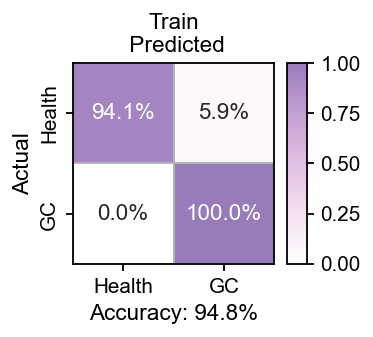

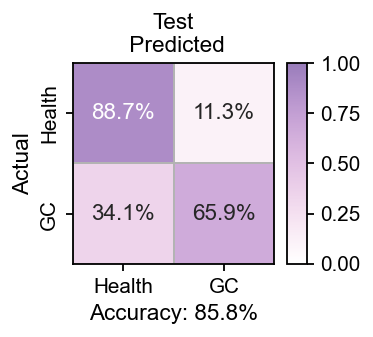

In [99]:
# blood only RC or GC vs. H
result_bl = blood_lopo_bootstrap_pipe(
    props_blood_all, type_c='GC',
    algorithm='brf',
    bag_size=48, 
    n_boot=None, # None,1000
    agg="mean", 
    cm_plot=True, # True
    cal_impo=True, # False
    random_state=4,
    sub_folder='blood_sample/H&GC')

In [1422]:
#tissue
import numpy as np
import pandas as pd
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample

def PTC_lopo_bootstrap_pipe(dataframe, bag_size=10, n_boot=1000, agg="mean", cm_plot=True, cal_impo=True, random_state=42):
    """
    df: DataFrame, columns: patient_id, normal (0/1), feature columns
    bag_size: number of EV to aggregate per bag
    n_boot: None or number of bootstrap iterations
    agg: "mean" or "median"
    cm_plot: bool. whether draw & save confusion_matrix img
    """
    np.random.seed(random_state)
    
    df = dataframe.copy(deep=True)
    num_2_type = {'EV CD63+ EpCAM+':1, 'EV CD63+ EpCAM-':0}
    df['type_num'] = [num_2_type[i] for i in df['normal']]   #1: cancer, 0: normal
    df['patient_id'] = df["cell"] +'_'+ df['normal']
    
    df.drop(columns=['centroid-0','centroid-1','label','orientation','area_filled','inertia_tensor-1-0',
                     'EV_id','protein',"cell",'normal'], inplace=True)#discard
    feature_cols = [c for c in df.columns if c not in ["type_num", "patient_id"]]
    
    
    # 1. EV bagging
    def aggregate_ev(df_patient):
        X = df_patient.drop(['patient_id','type_num'], axis=1).values
        y = df_patient['type_num'].iloc[0]
        n_ev = X.shape[0]
        bags = []
        labels = []
        for start in range(0, n_ev, bag_size):
            bag = X[start:start+bag_size] 
            if bag.shape[0] == 0:
                continue
            if agg == "mean":
                bag_features = bag.mean(axis=0)
            else:
                bag_features = np.median(bag, axis=0)
            bags.append(bag_features)
            labels.append(y)
        return np.array(bags), np.array(labels)
    
    # bag-level data
    X_bags_list = []
    y_bags_list = []
    patient_ids = df['patient_id'].unique()
    for pid in patient_ids:  
        df_p = df[df['patient_id']==pid]
        X_bags, y_bags = aggregate_ev(df_p)
        X_bags_list.append(X_bags)
        y_bags_list.append(y_bags)
    # concat
    X_bags_all = np.vstack(X_bags_list)
    y_bags_all = np.hstack(y_bags_list)
    
    patient_bag_counts = [len(x) for x in X_bags_list]
    
    # ---------2. LOPO CV----------
    all_y_true_train = []
    all_y_pred_train = []
    all_y_true_test = []
    all_y_pred_test = []
    
    for i, test_pid in enumerate(patient_ids):  #1 for testset
        test_start = sum(patient_bag_counts[:i])
        test_end = test_start + patient_bag_counts[i]
        test_idx = np.arange(test_start, test_end)
        train_idx = np.setdiff1d(np.arange(len(X_bags_all)), test_idx)
        
        X_train, y_train = X_bags_all[train_idx], y_bags_all[train_idx]
        X_test, y_test   = X_bags_all[test_idx], y_bags_all[test_idx]
        
        # pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('brf', BalancedRandomForestClassifier(
                n_estimators=200,
                sampling_strategy='all',
                bootstrap=False,
                random_state=random_state
            ))
        ])
        pipeline.fit(X_train, y_train)
        y_pred_train = pipeline.predict(X_train)
        y_pred_test = pipeline.predict(X_test)
        
        all_y_true_train.extend(y_train)
        all_y_pred_train.extend(y_pred_train)
        all_y_true_test.extend(y_test)
        all_y_pred_test.extend(y_pred_test)
    
    # accuracy & auc_score
    acc_train = accuracy_score(all_y_true_train, all_y_pred_train)
    acc_test = accuracy_score(all_y_true_test, all_y_pred_test)
    auc_test = roc_auc_score(all_y_true_test, all_y_pred_test)
    print(f"LOPO Accuracy_train:{acc_train:.4f}, Accuracy_test:{acc_test:.4f}, AUC:{auc_test:.4f}")
    
    # impo
    if cal_impo == True:
        impo = pipeline.named_steps['brf'].feature_importances_
        impo_df = pd.DataFrame(sorted(zip(impo, feature_cols), reverse=True))
        time_id = time.strftime("%Y-%m-%d_%H-%M-%S")
        save_path = os.path.join(ML_dir, 'RF_result', f'LOPO_impo_bg{bag_size}_{time_id}.xlsx')
        impo_df.to_excel(save_path, index=False)
    else: impo_df = None

    cm_train = confusion_matrix(all_y_true_train, all_y_pred_train)
    cm_test = confusion_matrix(all_y_true_test, all_y_pred_test)
    print(f"LOPO Confusion Matrix Train:{cm_train}")
    print(f"LOPO Confusion Matrix Test:{cm_test}")
    
    if cm_plot == True:
        conf_mat_heatmap(cm_train, 'Train', cmap=cmap1, save_name=f'LOPO_CM_Train_bg{bag_size}', figsize=(2.5,2.5), 
                         ticklabel=['Normal \n Group','Cancer \n Group'], density=True)
        conf_mat_heatmap(cm_test, 'Test', cmap=cmap1, save_name=f'LOPO_CM_Test_bg{bag_size}', figsize=(2.5,2.5), 
                         ticklabel=['Normal \n Group','Cancer \n Group'], density=True)
    
    result = {'cm_train':cm_train, 'cm_test':cm_test, 'acc_train':acc_train, 'acc_test':acc_test,
          'all_y_pred_train':all_y_pred_train, 'all_y_pred_test':all_y_pred_test, 'impo':impo_df}
    
    # --------3. Bootstrap-----------
    if n_boot is not None:
        boot_acc = []
        boot_auc = []
        for _ in range(n_boot): # patient-level resample
            # stratified bootstrap
            normal_pids = [p for p in patient_ids if df[df['patient_id']==p]['type_num'].iloc[0]==1]
            disease_pids = [p for p in patient_ids if df[df['patient_id']==p]['type_num'].iloc[0]==0]
            
            train_pids = np.random.choice(normal_pids, size=len(normal_pids), replace=True).tolist() + \
                         np.random.choice(disease_pids, size=len(disease_pids), replace=True).tolist()
            test_pids  = [p for p in patient_ids if p not in train_pids]
            if len(test_pids) == 0:
                continue
            
            # train
            train_idx = []
            for pid in train_pids:
                i = np.where(patient_ids==pid)[0][0]
                start = sum(patient_bag_counts[:i])
                end = start + patient_bag_counts[i]
                train_idx.extend(list(range(start,end)))
            # test
            test_idx = []
            for pid in test_pids:
                i = np.where(patient_ids==pid)[0][0]
                start = sum(patient_bag_counts[:i])
                end = start + patient_bag_counts[i]
                test_idx.extend(list(range(start,end)))
            X_train, y_train = X_bags_all[train_idx], y_bags_all[train_idx]
            X_test, y_test   = X_bags_all[test_idx], y_bags_all[test_idx]
    
            if len(np.unique(y_train)) < 2:
                continue  # skip this iteration
                
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            y_prob = pipeline.predict_proba(X_test)[:,1]
            
            boot_acc.append(accuracy_score(y_test, y_pred))
        
        print(f"Bootstrap Accuracy_test: {np.mean(boot_acc):.4f} ± {np.std(boot_acc):.4f}")
    
        result = {'cm_train':cm_train, 'cm_test':cm_test, 'acc_train':acc_train, 'acc_test':acc_test,
                  'all_y_pred_train':all_y_pred_train, 'all_y_pred_test':all_y_pred_test,
                  'boot_acc':boot_acc, 'impo':impo_df}
    return result

LOPO Accuracy_train:0.9626, Accuracy_test:0.8767, AUC:0.8795
LOPO Confusion Matrix Train:[[ 484    0]
 [  60 1062]]
LOPO Confusion Matrix Test:[[39  5]
 [13 89]]


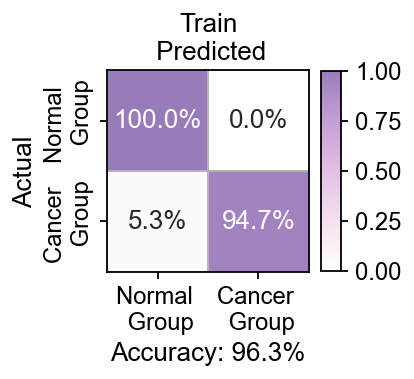

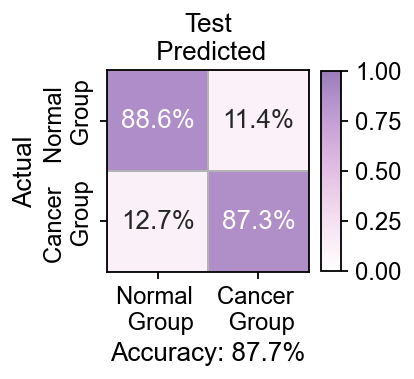

In [1471]:
result_1 = PTC_lopo_bootstrap_pipe(
    props_Clin_all_pickup, 
    bag_size=20, 
    n_boot=1000,#None, 
    agg="mean", 
    cm_plot=True, 
    cal_impo=True, 
    random_state=2)

## change_n

LOPO Accuracy_train:1.0000, Accuracy_test:0.8800, AUC:0.6487
LOPO Confusion Matrix Train:[[6102    0]
 [   0  873]]
LOPO Confusion Matrix Test:[[649  29]
 [ 64  33]]
LOPO Accuracy_train:1.0000, Accuracy_test:0.8725, AUC:0.6476
LOPO Confusion Matrix Train:[[5805    0]
 [   0  828]]
LOPO Confusion Matrix Test:[[611  34]
 [ 60  32]]
LOPO Accuracy_train:1.0000, Accuracy_test:0.8800, AUC:0.6487
LOPO Confusion Matrix Train:[[6102    0]
 [   0  873]]
LOPO Confusion Matrix Test:[[649  29]
 [ 64  33]]
LOPO Accuracy_train:1.0000, Accuracy_test:0.8725, AUC:0.6476
LOPO Confusion Matrix Train:[[5805    0]
 [   0  828]]
LOPO Confusion Matrix Test:[[611  34]
 [ 60  32]]
LOPO Accuracy_train:1.0000, Accuracy_test:0.8800, AUC:0.6487
LOPO Confusion Matrix Train:[[6102    0]
 [   0  873]]
LOPO Confusion Matrix Test:[[649  29]
 [ 64  33]]
LOPO Accuracy_train:1.0000, Accuracy_test:0.8725, AUC:0.6476
LOPO Confusion Matrix Train:[[5805    0]
 [   0  828]]
LOPO Confusion Matrix Test:[[611  34]
 [ 60  32]]


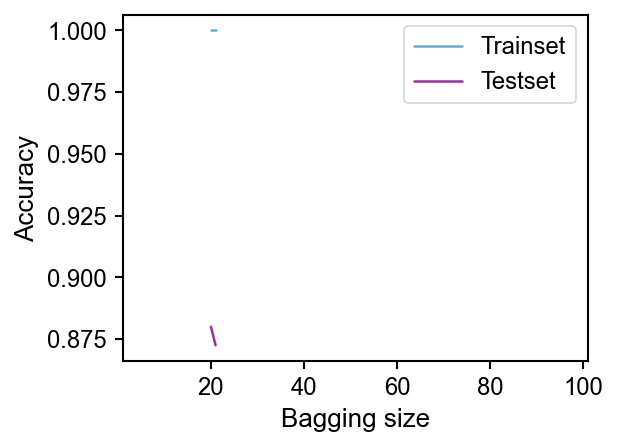

In [84]:
# change different n, observe accuracy
n_min = 1
n_max = 101
algorithm = ['brf']#'brf', 'lgb', 'svm'

for al in algorithm:
    res_n_accu_all = pd.DataFrame()
    for ran_s in range(0,5): #'brf' repeat for 5 times; 'lgb' and 'svm' do not have a random seed, no repeat
        res_n_accu = pd.DataFrame()
        for n in range(n_min, n_max):#
            result_2 = blood_lopo_bootstrap_pipe(
                props_blood_all.query("normal=='GC' or normal=='Health'"), 
                algorithm=al,
                bag_size=n, 
                n_boot=None, 
                agg="mean", 
                cm_plot=False, cal_impo=False, 
                random_state=ran_s, 
                sub_folder='blood_sample/H&GC')
            temp = pd.DataFrame([n, result_2['acc_train'], result_2['acc_test']])
            res_n_accu = pd.concat([res_n_accu, temp.T], axis=0)
        res_n_accu_all = pd.concat([res_n_accu_all, res_n_accu], axis=0)
        
    res_n_accu_all.columns=['n', 'accuracy_train', 'accuracy_test']
    time_id = time.strftime("%Y-%m-%d_%H-%M-%S")
    save_path = os.path.join(ML_dir, 'blood_sample/H&GC')
    xlsx_name = f'H&GC_LOPO_{al}_diff_{n_min}-{n_max}_{time_id}.xlsx'
    res_n_accu_all.to_excel(os.path.join(save_path, xlsx_name), index=False)
    
    draw_diff_n(res_n_accu_all, os.path.join(save_path, f'H&GC_LOPO_{al}_diff_{n_min}-{n_max}_{time_id}.svg'))

In [32]:
def draw_diff_n(res_n_accu_all, save_name=None):
    fig, ax1 = plt.subplots(figsize=(4,3), dpi=150)
    sns.lineplot(x='n', y='accuracy_train', data=res_n_accu_all, color='#64ADD9', #linewidth=1, 
                 errorbar='sd', err_style='band', 
                 err_kws={'alpha':0.6,'edgecolor':None,'facecolor':'#64ADD9'},#('ci', 95)
                 label='Trainset', ax=ax1)
    sns.lineplot(x='n', y='accuracy_test', data=res_n_accu_all, color='purple', #linewidth=1, #linestyle='--', 
                 errorbar='sd', err_style='band', alpha=0.8,
                 err_kws={'alpha':0.4,'edgecolor':None,'facecolor':'purple'},#bars
                 label='Testset', ax=ax1)
    ax1.set_ylabel('Accuracy', {'color':'black'}) 
    ax1.set_xlabel('Bagging size', {'color':'black'})
    #plt.vlines(x=10, ymin=0, ymax=1, color='gray', linestyle=':')
    plt.xlim([1, 101])
    #plt.ylim([0.5, 1.0])
    
    ax1.set_facecolor((1, 1, 1, 1)) #white
    plt.grid(False)
    plt.tick_params(bottom=True, left=True, width=1, length=4, colors="black")
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")
    h, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles=h, #loc='lower right', 
               #bbox_to_anchor=(1.02,1.02), fontsize=11
               facecolor='white', labelcolor='black', )
    if save_name is not None:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')

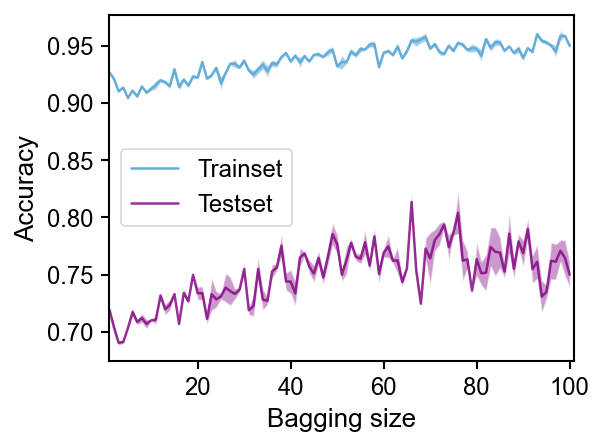

In [36]:
save_name = os.path.join(ML_dir, 'blood_sample/H&RC/H&RC_LOPO_brf_diff_1-101-temp.svg')
draw_diff_n(res_n_accu_all,save_name)

## impo

In [100]:
feature_groups = {
    "Size": ['area','area_bbox','area_convex','equivalent_diameter_area'],
    "Elongation & Anisotropy": ['axis_major_length','axis_minor_length','eccentricity'],
    "Shape Regularity & Convexity": ['solidity','feret_diameter_max','extent'],
    "Boundary Complexity": ['perimeter_crofton','perimeter'],
    "High-order Mass Distribution": [
        'moments_central-0-0','moments_central-0-1','moments_central-0-2','moments_central-0-3',
        'moments_central-1-0','moments_central-1-1','moments_central-1-2','moments_central-1-3', 
        'moments_central-2-0','moments_central-2-1','moments_central-2-2','moments_central-2-3', 
        'moments_central-3-0','moments_central-3-1','moments_central-3-2','moments_central-3-3',
        'inertia_tensor-0-0','inertia_tensor-0-1','inertia_tensor-1-1']
}
def assign_group(feature):
    for group, feats in feature_groups.items():
        if feature in feats:
            return group
    return "Other"

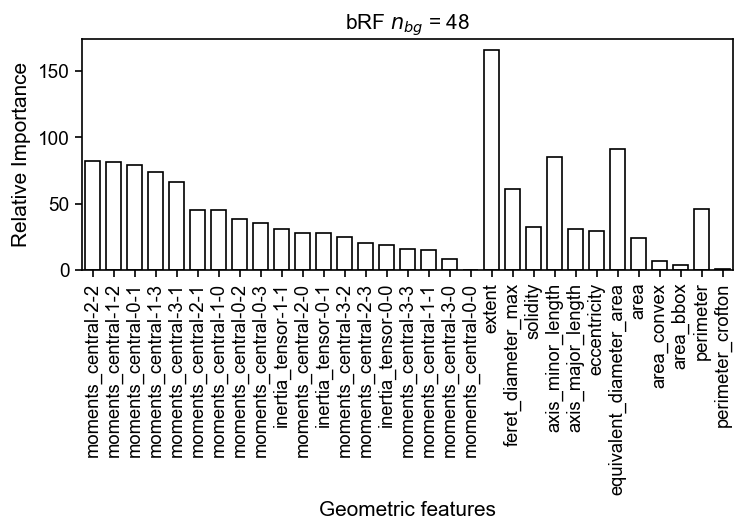

In [124]:
#from matplotlib.colors import LinearSegmentedColormap
def draw_impo_g(impo_df, f_title=None, cmap=None, order=None, save_fig=False, save_path=False):
    '''draw grouped impo_column
    f_title: str or None. figure title
    order: list or None. customized order of columns, or use ascending
    save_fig: bool. If True, save to pre-defined path and add time_id to file name
    save_path:str or None. customized save name and path.
    '''
    #------- order -------
    if order is None:
        group_importance = (impo_df.groupby("group")["val"].sum()
                            .sort_values(ascending=False))
        
        impo_df = impo_df.sort_values(by=["group","val"], ascending=[False, False])
        
        #final feature order
        ordered_features = []
        for group in group_importance.index:
            feats_in_group = (
                impo_df[impo_df["group"]==group]
                .sort_values("val", ascending=False)["feature"]
                .tolist()
            )
            ordered_features.extend(feats_in_group)
    else:
        ordered_features = order
    #------- fig -------
    fig, ax1 = plt.subplots(figsize=(7,2.5), dpi=120)
    ax1.set_facecolor("none")
    fig.patch.set_alpha(0)
    plt.grid(False)
    
    sns.barplot(x='feature', y='val', data=impo_df, errorbar=("ci",95), capsize=0.2,
                err_kws={"color":"black", "linewidth":1}, 
                width=0.7, linewidth=1, order=ordered_features,
                facecolor=(0, 0, 0, 0), edgecolor='black', ax=ax1) 
    ax1.set_ylabel('Relative Importance', {'color':'black'})
    ax1.set_xlabel('Geometric features', {'color':'black'})
    plt.xticks(rotation=90, fontsize=11, color='black')
    if f_title is not None:
        plt.title(f_title, color='black')
    plt.tick_params(bottom=True, left=True, width=1, length=4, colors="black")
    
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")
    if save_fig == True:
        time_id = time.strftime("%Y-%m-%d_%H-%M-%S")
        save_path = os.path.join(ML_dir, 'RF_result', f'NestedLOPO_impo_{time_id}.svg')
        plt.savefig(save_path, bbox_inches='tight', transparent=True, dpi=150)
    if save_path != False:
        plt.savefig(save_path, bbox_inches='tight', transparent=True, dpi=150)
    return ordered_features
_ = draw_impo_g(impo_df_all, f_title='bRF $n_{bg}$ = 48', save_fig=False, save_path=False)

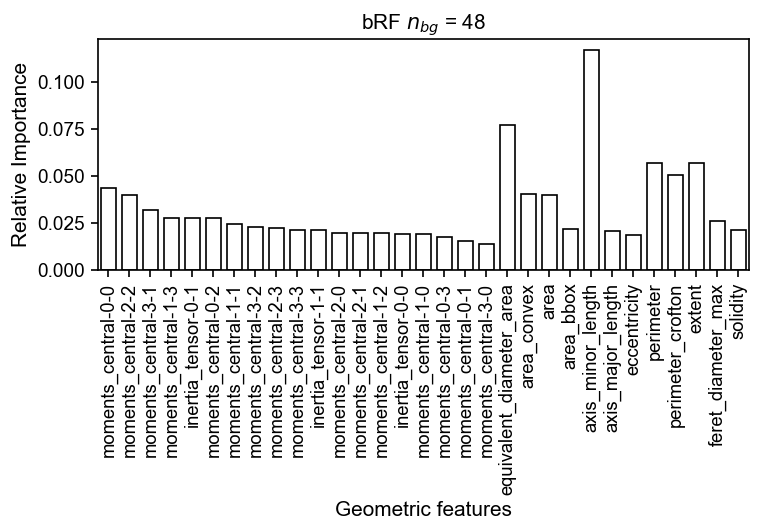

In [126]:
#load impo_data
impo_name = os.path.join(ML_dir,'blood_sample/H&GC', 'blood_LOPO_brf_impo_bg48_2026-05-24_13-13-03.xlsx')
impo_df_all = pd.read_excel(impo_name)
impo_df_all.columns = ['val', 'feature']
impo_df_all["group"] = impo_df_all["feature"].apply(assign_group)
#draw impo
save_path = os.path.splitext(impo_name)[0]+'.svg'
feature_order = draw_impo_g(impo_df_all, f_title='bRF $n_{bg}$ = 48', order=None, 
                            save_fig=False, save_path=False)